# Предобученные модели (Transfer learning)

<h2 style="text-align: center;"><b>Построение нейронной сети на основе предварительно обученной</b></h2>

Будем работать с датасетом, который не входит в набор стандартных датасетов библиотеки Keras, поэтому данные придется загружать из внешнего источника.

Загрузим датасет для бинарной классификации кошек и собак. Попробуем научить сеть различать кошек и собаки.

In [1]:
# Импортируем функцию для загрузки картинок из файлов и генератор картинок
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
import numpy as np
from matplotlib import pyplot as plt

#### 1. Загрузка данных

In [2]:
!curl -o Cat_Dog_data.zip https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
!tar -xf Cat_Dog_data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0  553M    0 16985    0     0  19558      0  8:14:40 --:--:--  8:14:40 19590
  0  553M    0 1172k    0     0   655k      0  0:14:24  0:00:01  0:14:23  655k
  0  553M    0 3766k    0     0  1368k      0  0:06:54  0:00:02  0:06:52 1368k
  1  553M    1 6214k    0     0  1650k      0  0:05:43  0:00:03  0:05:40 1650k
  1  553M    1 8822k    0     0  1850k      0  0:05:06  0:00:04  0:05:02 1850k
  2  553M    2 11.3M    0     0  2021k      0  0:04:40  0:00:05  0:04:35 2374k
  2  553M    2 13.9M    0     0  2109k      0  0:04:28  0:00:06  0:04:22 2630k
  2  553M    2 16.5M    0     0  2181k      0  0:04:19  0:00:07  0:04:12 2626k
  3  553M    3 19.1M    0     0  2241k      0  0:04:12  0:00:08  0:04:04 2688k
  3  553M    3 21.9M    0     0  2308k      0  0:04

Теперь наши данные хранятся в папке `Cat_Dog_data` с разделением на поддиректории `train` и `test`.

Элементы каждого класса хранятся в своей директории (`cat` или `dog`).

In [7]:
import os.path
base_dir = 'Cat_Dog_data'

train_dir = os.path.join(base_dir, 'train')

test_dir = os.path.join(base_dir, 'test')

In [8]:
from os import listdir, sep
from os.path import abspath, basename, isdir
def tree(dir, padding= '  ', print_files=False):
    """
    Эта функция строит дерево поддиректорий и файлов для заданной директории

    Параметры
    ----------
    dir : str
        Path to needed directory
    padding : str
        String that will be placed in print for separating files levels
    print_files : bool
        "Print or not to print" flag
    """
    cmd = "find '%s'" % dir
    files = os.popen(cmd).read().strip().split('\n')
    padding = '|  '
    for file in files:
        level = file.count(os.sep)
        pieces = file.split(os.sep)
        symbol = {0:'', 1:'/'}[isdir(file)]
        if not print_files and symbol != '/':
            continue
        print (padding*level + pieces[-1] + symbol)

In [9]:
def plot_cats_dogs_samples(train_dir, N=4):
  """
    Эта функция строит N сэмплов каждого класса из датасета Cats vs Dogs

    Параметры
    ----------
    train_dir : str
        Directory with train Cats vs Dogs dataset
    N : int
        Number of samples for each class
  """
  import random
  fig, ax = plt.subplots(2,N,figsize=(5*N,5*2))

  for i,name in enumerate(['cat','dog']):
    filenames = os.listdir(os.path.join(train_dir,name))

    for j in range(N):
      sample = random.choice(filenames)
      image = load_img(os.path.join(train_dir,name,sample))
      ax[i][j].imshow(image)
      ax[i][j].set_xticks([])
      ax[i][j].set_yticks([])
      ax[i][j].set_title(name)
  plt.grid(False)
  plt.show()

In [10]:
# Посмотрим, как именно расположены директории с датасетом относительно друг друга
tree(base_dir,print_files=False)

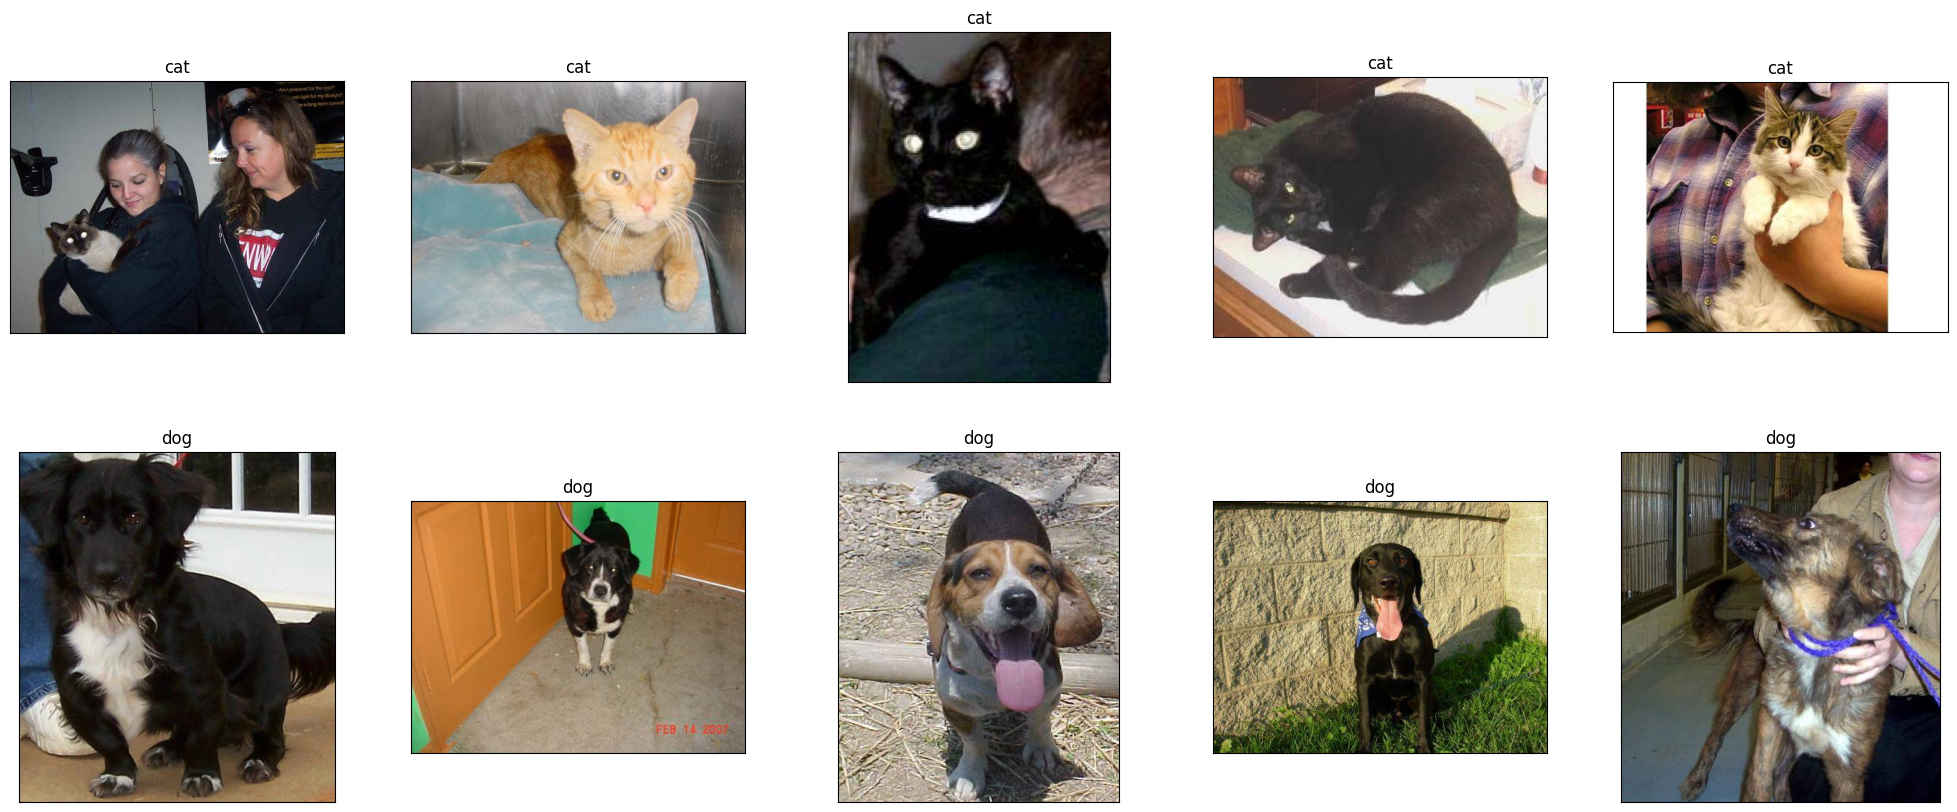

In [11]:
#Посмотрим на содержание датасета при помощи функции plot_cats_dogs_samples
plot_cats_dogs_samples(train_dir, N=5)

### 2. Подготовка данных


Такой формат хранения удобен для использования функции генератора изображений `flow_from_directory`.

Генератор не будет выкачивать все данные в оперативную память, а будет поочередно считывать из директорий нужные изображения и складывать их в батчи.

Создадим `ImageDataGenerator` для трейновой и тестовой выборок, поскольку обе выборки нужно доставать из директорий.

Укажем преобразование, нормализующее изображения

In [12]:
# Импортируем сам keras
import keras
# Последовательный тип модели
from keras.models import Sequential
# Импортируем полносвязный слой, слои активации и слой,
# превращающий картинку в вектор
from keras.layers import Dense, Activation, Flatten
# Импортируем сверточный слой, слои, фильтрующий максимальные значения из
# входных данных, слой "выключающий часть нейронов"
from keras.layers import Conv2D, MaxPooling2D, Dropout

In [13]:
# Эти библиотеки отключают лишние предупреждения от библиотек, в частности,
# tensorflow, чтобы не засорять вывод наших результатов
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
from tensorflow.python.util import deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False
import warnings
warnings.filterwarnings("ignore")

In [14]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

Зададим поток тренировочных батчей из директории **train** и **test**;

Приведем все изображения к одному квадратному формату;

Укажем, что работаем с задачей бинарной классификации

In [15]:
#Теперь для создания генератора вместо метода flow мы пользуемся
# flow_from_directory

train_generator = train_datagen.flow_from_directory(
        train_dir,  # Путь к директории с трейновой выборкой
        target_size=(150, 150),  # Размер изображений, к которому нужно привести все данные
        batch_size=128,
        #Генератор автоматически расставит бинарные лейблы для классов cat и dog
        class_mode='binary')


test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(150, 150),
        batch_size=128,
        class_mode='binary')

Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [16]:
# Соотношение между номером класса и его названием запишем в словарь
LABEL_DICT={1:'dog',0:'cat'}

In [17]:
def plot_dataset_samples_grid(image_data, dataset_name='', N=8):
  """
    Эта функция строит NxN самплов из датасета image_data

    Параметры
    ----------
    image_data : array
        Array of shape
        (number_of_samples, image_width, image_height, number of channels)
        with images
    dataset_name : str
        Name of dataset to write in the title
    N : int
        Size of grid of samples
  """
  plt.figure(figsize=(10,10))
  data1=image_data[:N*N]

  image_width=image_data.shape[1]
  image_heigth=image_data.shape[2]

  if len(data1.shape)==4:
    image_channels=image_data.shape[3]
    data1 = data1.reshape(N, N,image_width,image_heigth, image_channels)
    data1 = np.transpose(data1,(0,2,1,3,4))
    data1 = data1.reshape(N*image_width,N*image_heigth,image_channels)
    plt.imshow(data1)

  elif len(data1.shape)==3:
    data1 = data1.reshape(N, N,image_width,image_heigth)
    data1 = np.transpose(data1,(0,2,1,3))
    data1 = data1.reshape(N*image_width,N*image_heigth)
    plt.imshow(data1,cmap='gray')
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.title('First '+ str(N*N) + ' '+dataset_name+ ' samples of training set')
  plt.show()

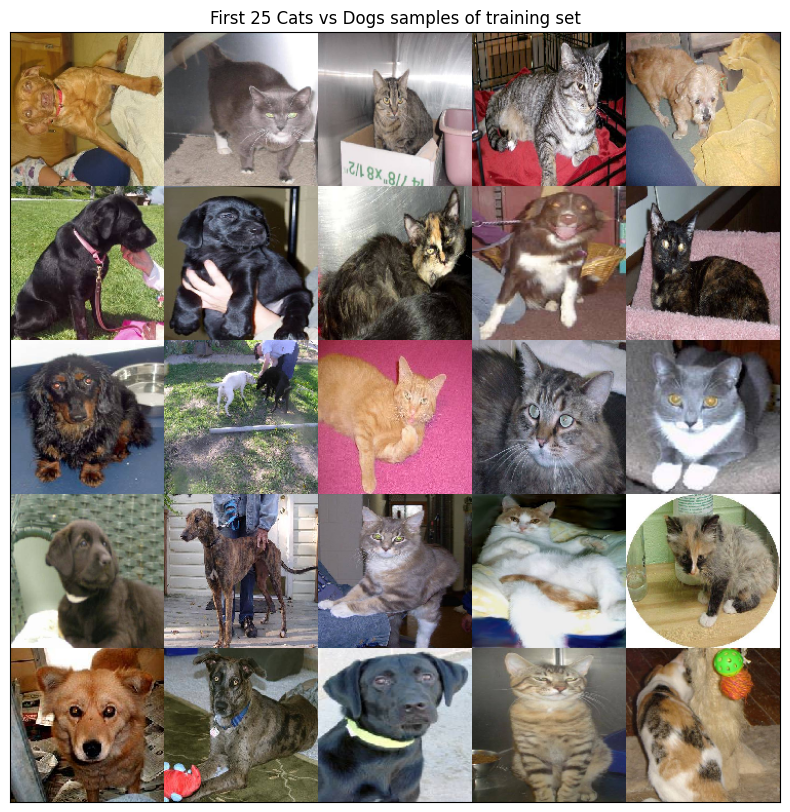

In [18]:
# train_generator является итератором, т.е., чтобы получить батч элементов
# нужно выполнить какую-то итерирующую функцию: например, цикл for
for img in train_generator:
  img=img[0]
  break

#Посмотрим, какие у нас вышли картинки при помощи функции plot_dataset_samples_grid
plot_dataset_samples_grid(img,'Cats vs Dogs', N=5)

### 3. Baseline
Для сравнения построим небольшую  baseline сверточную модель, состоящую из трех блоков **conv-maxpool** и пары полносвязных слоев.



Размер входящего изображения `input_shape`=($150$, $150$, $3$), активация последнего слоя - `sigmoid` вместо `softmax`, поскольку мы работаем с бинарной классификацией. На выходе мы получим вероятность от $0$ до $1$, что картинка принадлежит к классу $1$ (**dog**).

In [19]:
def define_model():
  # Создаем пустую модель
  model = Sequential()

#1й сверточный блок
  # Начинаем со сверточных слоев, указывая тип активации ReLU
  model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(150, 150, 3)))
  # Здесь мы используем метод MaxPooling, который уменьшает размер обрабатываемого изображения,
  # выбирая из 4 пикселей 1 с максимальным значением, чтобы это быстрее считалось. (2,2) -> 1
  model.add(MaxPooling2D((2, 2)))

#2й сверточный блок
  model.add(Conv2D(32, (3, 3), activation='relu'))
  model.add(MaxPooling2D((2, 2)))

#3й сверточный блок
  model.add(Conv2D(64, (3, 3), activation='relu'))
  model.add(MaxPooling2D((2, 2)))

  # Разворачиваем данные в вектор
  model.add(Flatten())
  # Добавляем полносвязные слои:
  # ReLU активация скрытого слоя
  model.add(Dense(512, activation='relu'))
  # Sigmoid в качестве активации и одна выходная переменная -
  # вероятность, что картинка принадлежит к классу 1
  model.add(Dense(1, activation='sigmoid'))


  # Компилируем модель с функцией ошибки binary crossentropy, оптимизатором Адам
  # (оптимизатор, который со стандартным набором параметров может обучить эффективную
  # нейросеть), и метрикой - количеством правильно угаданных картинок.
  model.compile(loss='binary_crossentropy',
                  optimizer = 'adam',
                  metrics = ['accuracy'])
  return model

In [20]:
# Создаем новую модель
base_model = define_model()

In [21]:
#Посмотрим, из чего наша модель состоит
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = base_model.fit(
      train_generator,
      epochs=1,
      validation_data=test_generator)

176/176 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.6494 - loss: 0.6097 - val_accuracy: 0.7392 - val_loss: 0.5345


Epoch 1/7
176/176 [==============================] - 70s 400ms/step - loss: 0.6378 - accuracy: 0.6406 - val_loss: 0.5305 - val_accuracy: 0.7060
Epoch 2/7
176/176 [==============================] - 68s 386ms/step - loss: 0.4902 - accuracy: 0.7629 - val_loss: 0.5897 - val_accuracy: 0.7572
Epoch 3/7
176/176 [==============================] - 67s 380ms/step - loss: 0.4242 - accuracy: 0.8044 - val_loss: 0.5435 - val_accuracy: 0.7836
Epoch 4/7
176/176 [==============================] - 66s 375ms/step - loss: 0.3693 - accuracy: 0.8354 - val_loss: 0.4427 - val_accuracy: 0.7840
Epoch 5/7
176/176 [==============================] - 66s 377ms/step - loss: 0.3105 - accuracy: 0.8670 - val_loss: 0.4172 - val_accuracy: 0.8044
Epoch 6/7
176/176 [==============================] - 67s 378ms/step - loss: 0.2449 - accuracy: 0.8980 - val_loss: 0.5828 - val_accuracy: 0.8072
Epoch 7/7
176/176 [==============================] - 66s 376ms/step - loss: 0.1898 - accuracy: 0.9232 - val_loss: 0.4192 - val_accuracy: 0.8148

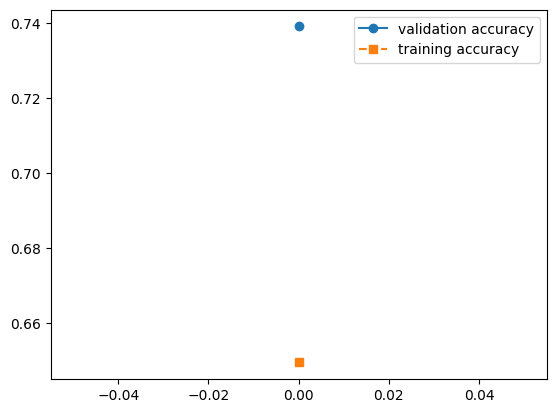

In [24]:
# Построим изменение точности на обучающей (рыжая линия) и тестовой (синяя линия)
# выборках
plt.plot(history.history['val_accuracy'], '-o', label='validation accuracy')
plt.plot(history.history['accuracy'], '--s', label='training accuracy')
plt.legend();

In [25]:
# Взглянем на итоговые результаты классификации на тестовой выборке
# (функция ошибки, точность)
base_model.evaluate(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.7392 - loss: 0.5345


[0.534461498260498, 0.7391999959945679]

20/20 [==============================] - 7s 329ms/step

[0.5936983227729797, 0.8148000240325928]

Видно, что точность на тестовой выборке практически сразу вышла на плато около  0.8 , а точность на обучающей выборке почти достигла  1 , поэтому с такой моделью улучшить точность на новых данных уже вряд ли выйдет.

## 4. Transfer learning

Использование предобученных моделей для новых задач

Как уже упоминалось ранее, есть архитектуры нейросетей, которые зарекомендовали себя в решении определенного класса задач, как, например, **VGG16**.

<img src="https://www.researchgate.net/profile/Max_Ferguson/publication/322512435/figure/download/fig3/AS:697390994567179@1543282378794/Fig-A1-The-standard-VGG-16-network-architecture-as-proposed-in-32-Note-that-only.png" width="700">


**VGG16** и подобные ей модели содержат большое количество параметров и обучение их с нуля может занять большое количество времени (а на домашнем ноутбуке это время стремится к бесконечности).

Кроме того, бывают задачи, где данных изначально небольшое количество и даже аугментация не сильно спасает положение, тогда обучение сверточной сети может быть не очень успешным.

Поэтому можно использовать модель, которая уже была кем-то предобучена, загрузить ее веса и дообучать только последние слои, подстраивая их под свою конкретную задачу.

#### Нам необходимо:

1.   Загрузить предобученную VGG16 модель без последних полносвязных слоев, отвечающих за конкретную задачу
2.   Построить свою полносвязную сеть для бинарной классификации кошек и собак
3.   Соединить две модели в одну.



### 1) Подготовим данные

Создадим `ImageDataGenerator` для трейновой и тестовой выборок,
указав преобразование, нормализующее изображения

In [26]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

Изменим размеры картинок dataloader, поскольку модель **VGG16** принимает входные значения стандартизированного размера $224$х$224$x$3$.

Зададим поток тренировочных батчей из директории **train** и **test**.

Приведем все изображения к одному квадратному формату.

Укажем, что работаем с задачей бинарной классификации.

In [27]:
train_generator = train_datagen.flow_from_directory(
        train_dir,  # Путь к директории с трейновой выборкой
        target_size=(224, 224),  # Размер изображений, к которому нужно привести все данные
        batch_size=128,
        #Генератор автоматически расставит бинарные лейблы для классов cat и dog
        class_mode='binary')


test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=128,
        class_mode='binary')

Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


### 2) Загрузим VGG16

В библиотеке `Keras` уже представлены архитектуры **State-of-the-art** моделей, поэтому можно достать **VGG16** модель одной строчкой кода.

In [28]:
from keras.applications import vgg16 as vgg

Создадим **VGG** модель, в качестве параметра `weights` укажем `imagenet` - название
большого датасета с картинками, на котором сеть была натренирована;

`include_top` - False - не включать полносвязные слои вверху нейросети

In [29]:
vgg_model = vgg.VGG16(weights='imagenet',
                       include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [30]:
#Посмотрим, из чего состоит VGG модель
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Достанем последний слой `block5_pool` из **VGG** модели.

Над ним (или после него) построим наш классификатор.

In [31]:
last = vgg_model.get_layer('block5_pool').output

## 5. Global Average Pooling, Batch Normalization

**Global Average Pooling (GAP)**

Вместо того, чтобы изпользовать слой **Flatten** между сверточными и полносвязными слоями, который просто превращает выходные данные из свертки в вектор, можно посчитать среднее число для каждого канала свернутого изображения и передать полученный вектор полносвязным слоям.


**Batch Normalization**

Мы нормализуем входные данные нейросети, почему бы тогда не попробовать использовать нормализацию не только на входе, но и внутри модели?



### 3) Добавим небольшую нейросеть для бинарной классификации

In [32]:
# Модуль, с помощью которого мы будем "сшивать" последовательные модели
from keras import Model
# Импортируем Pooling по всему слою входных данных и нормализацию батчей
from keras.layers import GlobalAveragePooling2D, BatchNormalization

Добавим сверху слоя `last` **VGG** модели свои слои для классификации

In [33]:
# Добавим новые GAP (вместо FLatten) и BatchNormalization слои
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)

# Привычные полносвязные слои
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
pred = Dense(1, activation='sigmoid')(x)

Объединим **VGG16** и **классификатор** в одного трансформера при помощи модуля `Model`

In [34]:
fin_model = Model(vgg_model.input, pred)

Теперь самое важное: нам не нужно изменять и так хорошо натренированные веса
исходной модели, поэтому мы **"замораживаем"** их, при обучении сети они будут использоваться
только для вычисления выходных данных

In [35]:
for layer in vgg_model.layers:
     layer.trainable = False

In [36]:
# Скомпилируем модель с функцией ошибки binary crossentropy, оптимизатором Адам
# (оптимизатор, который со стандартным набором параметров может обучить эффективную
# нейросеть), и метрикой - количеством правильно угаданных картинок.
fin_model.compile(loss='binary_crossentropy',
                  optimizer = 'adam',
                  metrics = ['accuracy'])

In [37]:
fin_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 15,110,977 (57.64 MB)

 Trainable params: 395,265 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [38]:
# Обучим модель (5 эпох)
history_cnn = fin_model.fit(train_generator,
              epochs=1,
              validation_data=test_generator,
              shuffle=True)

176/176 ━━━━━━━━━━━━━━━━━━━━ 1238s 7s/step - accuracy: 0.8978 - loss: 0.2353 - val_accuracy: 0.9052 - val_loss: 0.3474


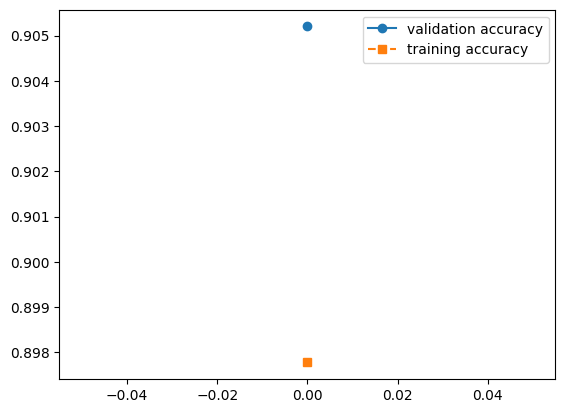

In [39]:
plt.plot(history_cnn.history['val_accuracy'], '-o', label='validation accuracy')
plt.plot(history_cnn.history['accuracy'], '--s', label='training accuracy')
plt.legend();
#plt.plot(history.history['val_accuracy'], '-o', label='validation accuracy')
#plt.plot(history.history['accuracy'], '--s', label='training accuracy')
#plt.legend();

In [40]:
fin_model.evaluate(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 123s 6s/step - accuracy: 0.9052 - loss: 0.3474


[0.347395122051239, 0.9052000045776367]

Использование предобученной модели **VGG** уже с 1й эпохи позволило нейросети достичь точности $>90$% на тестовой выборке!

Хотя здесь изменение точности вышло на плато, текущий результат сильно превосходит бейзлайн и позволяет на его основе строить еще более мощные предсказательные модели.

### 4) Посмотрим на картинки с наибольшей ошибкой


Найдем все предсказания на тестовой выборке и посмотрим, на каких картинках нейросеть
ошиблась больше всего.

In [41]:
# Создадим генератор картинок из тестовой выборки
test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=200,
        class_mode='binary',shuffle=False)

Found 2500 images belonging to 2 classes.


In [43]:
def get_test_predictions(test_generator, model, dataset_len=2500):
  """
    Эта функция вытаскивает из генератора все предсказания

    Параметры
    ----------
    test_generator  : ImageDataGenerator
        Generator, producing batches (img, label)
    model : keras.model
        Model for getting predictions
    dataset_len : int
        Number of samples in generator

    Returns
    ----------
    preds_labels  : array
        Predicted labels
    preds_vec : array
        Predicted probabilities
    labels_vec : array
        True labels
    datas_vec : array
        Array of images
  """
  labels=[]
  preds=[]
  datas=[]

  samples=0
  for i,batch in enumerate(test_generator):
    data, label=batch
    labels.append(label)
    preds.append(model.predict(data))
    datas.append(data)
    samples+=len(data)
    if samples>=dataset_len:
      break

  labels_vec=np.hstack(labels)
  preds_vec=np.hstack([pred.reshape(-1,) for pred in preds])
  datas_vec=np.vstack(datas)
  preds_labels=preds_vec.copy()
  preds_labels[preds_labels<0.5]=0
  preds_labels[preds_labels>=0.5]=1

  return preds_labels, preds_vec, labels_vec, datas_vec

In [44]:
preds_labels, preds_vec, labels_vec, datas_vec = get_test_predictions(test_generator, fin_model)

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


Найдем вектор ошибок, который для каждого предсказания `preds_labels[i]`
будет содержать значение **True**, если модель ошиблась и **False**, если угадала `labels_vec[i]` верно.


In [45]:
errors = labels_vec!=preds_labels

In [46]:
def display_errors(errors_index,img_errors,pred_errors, obs_errors):
    """
    Эта функция показывает 6 картинок с предсказанными и настоящими классами
    """
    label_dict={0.:'cat',1.:'dog'}
    n = 0
    nrows = 5
    ncols = 5
    fig, ax = plt.subplots(nrows,ncols,sharex=True,sharey=True,figsize=(15,10))
    for row in range(nrows):
        for col in range(ncols):
            error = errors_index[n]
            ax[row,col].imshow((img_errors[error]).reshape((224,224,3)),cmap='gray')
            ax[row,col].set_title("Predicted label :{}\nTrue label :{}".format(label_dict[pred_errors[error]],label_dict[obs_errors[error]]))
            n += 1
    plt.tight_layout()

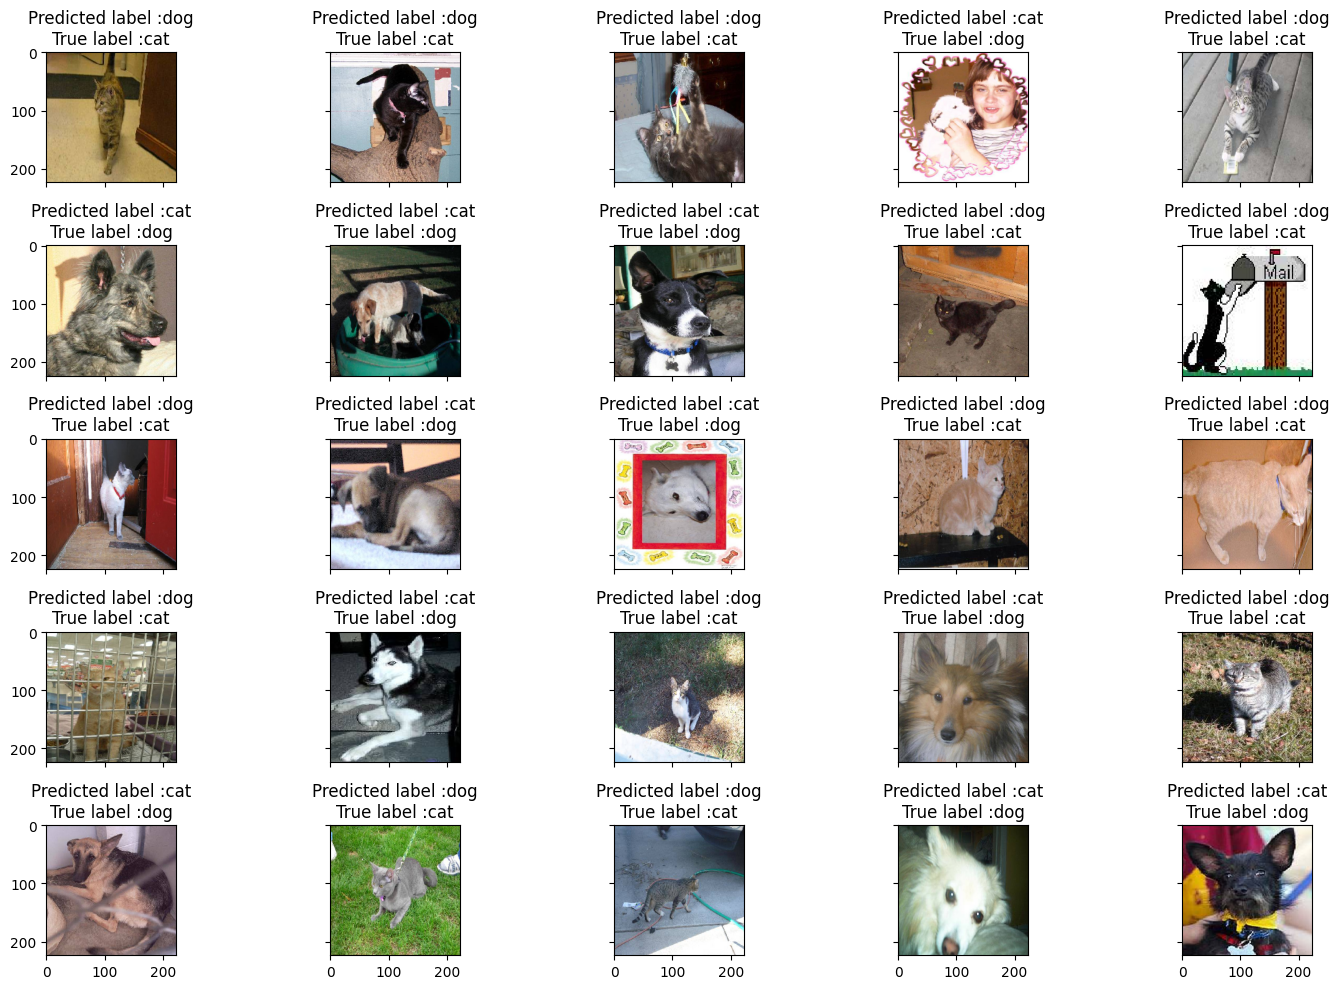

In [47]:
# Выделим из векторов предсказаний и настоящих лейблов только те,
# где нейросеть допустила ошибку
Y_pred_classes_errors = preds_labels[errors]
Y_pred_errors = preds_vec[errors]
Y_true_errors = labels_vec[errors]
X_val_errors = datas_vec[errors]

# Вероятности неправильно предсказанных классов
Y_pred_errors_prob = Y_pred_errors

# Вероятности, соответствующие правильным классам
true_prob_errors = 1-Y_pred_errors

# Разница вероятностей правильного и неправильного классов
delta_pred_true_errors = np.abs(Y_pred_errors_prob - true_prob_errors)

# Отсортированный списоц разниц вероятностей
sorted_dela_errors = np.argsort(delta_pred_true_errors)

# 25 наибольших ошибок
most_important_errors = sorted_dela_errors[-25:]

# Построим самые ошибочные rfhnbyrb
display_errors(most_important_errors, X_val_errors, Y_pred_classes_errors, Y_true_errors)

### Задание
Попробуйте улучшить результаты работы модели при помощи:

a.	Aугментации исходных данных (Добавить в ImageDataGenerator различные трансформации)

b.	Увеличения числа обучаемых параметров.

Чем ближе слои модели к выходному слою, тем больше веса зависят от конкретной задачи.
Изначально мы заморозили все слои модели vgg_model, теперь можно заморозить, например, первые 15 слоев, а остальные сделать обучаемыми.


In [ ]:
import tensorflow as tf
import os
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Параметры
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5

train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

base_dir = 'Cat_Dog_data'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Загрузка данных
train_generator_augmented = train_datagen_augmented.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

def create_correct_improved_model():
    # Загружаем предобученную VGG16
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    print("Всего слоев в базовой модели:", len(base_model.layers))
    
    for layer in base_model.layers[:15]:
        layer.trainable = False
    
    for layer in base_model.layers[15:]:
        layer.trainable = True
    
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(), 
        layers.Dropout(0.4),
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

correct_model = create_correct_improved_model()

# Компиляция
correct_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

correct_model.summary()

# Функция для визуализации обучения
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

# Обучаем модель
print("\nНАЧАЛО ОБУЧЕНИЯ УЛУЧШЕННОЙ МОДЕЛИ...")
print(f"Тренировочные данные: {train_generator_augmented.samples} изображений")
print(f"Валидационные данные: {val_generator.samples} изображений")
print(f"Эпох: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")

# Замер времени обучения
import time
start_time = time.time()

history = correct_model.fit(
    train_generator_augmented,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"\nОбщее время обучения: {training_time:.1f} секунд")
print(f"Среднее время на эпоху: {training_time/EPOCHS:.1f} секунд")

# Визуализируем результаты обучения
print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ...")
plot_training_history(history)

# Оцениваем модель на валидационных данных
print("\nОЦЕНКА МОДЕЛИ НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_loss, val_accuracy = correct_model.evaluate(val_generator, verbose=1)
print("="*50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print("="*50)
print(f"Валидационная точность: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Валидационные потери: {val_loss:.4f}")
print("="*50)

# Функция для предсказания на одном изображении
def predict_single_image(model, image_path):
    """
    Предсказание класса для одного изображения
    """
    try:
        # Загрузка и предобработка изображения
        img = keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0) 
        img_array /= 255.0
        
        # Предсказание
        prediction = model.predict(img_array, verbose=0)
        probability = prediction[0][0]
        
        # Интерпретация результата
        if probability > 0.5:
            class_name = "СОБАКА"
            confidence = probability
        else:
            class_name = "КОШКА" 
            confidence = 1 - probability
            
        return {
            'class': class_name,
            'confidence': confidence,
            'probability': probability,
            'message': f"🐕 {class_name} (вероятность: {confidence:.2%})" if class_name == "СОБАКА" 
                      else f"🐈 {class_name} (вероятность: {confidence:.2%})"
        }
        
    except Exception as e:
        return {'error': f"Ошибка при обработке изображения: {str(e)}"}

# Функция для пакетного предсказания
def predict_multiple_images(model, image_paths):
    """
    Предсказание для нескольких изображений
    """
    results = []
    for image_path in image_paths:
        result = predict_single_image(model, image_path)
        results.append((image_path, result))
    return results

print(f"\nТочность: {val_accuracy*100:.1f}%")

# Дополнительная статистика
print("\nСТАТИСТИКА ДАННЫХ:")
print(f"Классы: {list(train_generator_augmented.class_indices.keys())}")
print(f"Соответствие классов: {train_generator_augmented.class_indices}")